**Import Libraries**

In [2]:
import os   #Used for file and folder handling
import cv2   #Used for image processing
import numpy as np   #Used for numerical and array operations
import matplotlib.pyplot as plt   #Used for image visualization

**Connect Google Drive**

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In this step it connects Google Drive to Google Colab so that datset  files can be accessed directly.

**Set Project Path**

In [ ]:
PROJECT_PATH = "/content/drive/MyDrive/Crop_Disease_Project"

**Set Dataset Path**

In [ ]:
dataset_path = f"{PROJECT_PATH}/datasets/PlantVillage"

**Load Saved Dataset**


In [ ]:
classes = os.listdir(dataset_path)   #Read all disease class folders

print("Total Classes:", len(classes))   #Print total number of classes
print(classes[:10])   #Display first 10 classes

Total Classes: 16
['Tomato_Septoria_leaf_spot', 'Tomato_healthy', 'Tomato__Tomato_mosaic_virus', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_Early_blight', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Bacterial_spot']


This step reads all plant disease category folders from the dataset.

**Load Images & Labels**

In [ ]:
images = []   #Empty list to store images
labels = []   #Empty list to store labels

#Loop through each class folder
for class_name in classes:

    #Create class folder path
    class_path = os.path.join(dataset_path, class_name)

    #Loop through all images inside class
    for image_name in os.listdir(class_path):

        #Create complete image path
        image_path = os.path.join(class_path, image_name)

        #Read image using OpenCV
        image = cv2.imread(image_path)

        #Skip corrupted images
        if image is None:
            continue

        #Convert image from BGR to RGB
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        #Resize image to fixed size for deep learning
        image = cv2.resize(image, (224, 224))

        #Store processed image
        images.append(image)

        #Store corresponding label
        labels.append(class_name)

print("Total Images:", len(images))   #Print total loaded images

Total Images: 20637


This is the main preprocessing step.

for code:
1. Reads all images from dataset folders.
2. Converts image color format.
3. Resizes images.
4. Stores images and labels separately.

About resize 224*224 is because the most deep learning models like ResNet, MobileNet uses 224**224 image size as a standard input.

OpenCV loads images in BGR formate, but deep learning models expexts RGB formate.

**Load Classes**

**Convert into NumPy Arrays**

In [ ]:
#Convert image list into NumPy array
images = np.array(images)

#Convert label list into NumPy array
labels = np.array(labels)

print(images.shape)   #Print image dataset shape
print(labels.shape)   #Print label dataset shape

(20637, 224, 224, 3)
(20637,)


Lists are converted into NumPy arrays for efficient processing.

Deep learning frameworks work faster with NumPy arrays compared to Python lists.

**Save Dataset**

In [ ]:
#Create processed_data folder if not exists
os.makedirs(
    f"{PROJECT_PATH}/processed_data",
    exist_ok=True
)

#Save image array
np.save(
    f"{PROJECT_PATH}/processed_data/images.npy",
    images
)

#Save label array
np.save(
    f"{PROJECT_PATH}/processed_data/labels.npy",
    labels
)

print("Dataset Saved Successfully!")

Dataset Saved Successfully!


**Save Compressed Dataset**

In [ ]:
# #Save images and labels together in compressed format
# #.npz reduces storage size and keeps multiple arrays in one file
# np.savez_compressed(
#     f"{PROJECT_PATH}/processed_data/dataset.npz",
#     images=images,
#     labels=labels
# )

# print("dataset.npz saved successfully!")   # Print confirmation message

dataset.npz saved successfully!


**Load Saved Dataset**

In [ ]:
# #Load compressed dataset file
# data = np.load(
#     f"{PROJECT_PATH}/processed_data/dataset.npz"
# )

# #Extract images from dataset
# images = data["images"]

# #Extract labels from dataset
# labels = data["labels"]

# print(images.shape)    #Print loaded image shape
# print(labels.shape)    #Print loaded label shape

(20637, 224, 224, 3)
(20637,)


# New Process

In [ ]:
DATASET_PATH = "/Users/manish/Documents/Semister 2/7. Project/Aarti Data Droplet/plantVillage dataset/color"

SAVE_PATH = "/Users/manish/Documents/Semister 2/7. Project/Aarti Data Droplet"

os.makedirs(SAVE_PATH, exist_ok=True)
print(f"Dataset path : {DATASET_PATH}")
print(f"Save path    : {SAVE_PATH}")


Dataset path : /Users/manish/Documents/Semister 2/7. Project/Aarti Data Droplet/plantVillage dataset/color
Save path    : /Users/manish/Documents/Semister 2/7. Project/Aarti Data Droplet


In [ ]:
# Read all class folder names
classes = [
    c for c in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, c))
    and not c.startswith(".")
]
classes.sort()

print(f"Total Classes: {len(classes)}")
print()
for c in classes:
    count = len([
        f for f in os.listdir(os.path.join(DATASET_PATH, c))
        if not f.startswith(".")
    ])
    print(f"  {count:>5}  {c}")

Total Classes: 38

    630  Apple___Apple_scab
    621  Apple___Black_rot
    275  Apple___Cedar_apple_rust
   1645  Apple___healthy
   1502  Blueberry___healthy
   1052  Cherry_(including_sour)___Powdery_mildew
    854  Cherry_(including_sour)___healthy
    513  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
   1192  Corn_(maize)___Common_rust_
    985  Corn_(maize)___Northern_Leaf_Blight
   1162  Corn_(maize)___healthy
   1180  Grape___Black_rot
   1383  Grape___Esca_(Black_Measles)
   1076  Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
    423  Grape___healthy
   5507  Orange___Haunglongbing_(Citrus_greening)
   2297  Peach___Bacterial_spot
    360  Peach___healthy
    997  Pepper,_bell___Bacterial_spot
   1478  Pepper,_bell___healthy
   1000  Potato___Early_blight
   1000  Potato___Late_blight
    152  Potato___healthy
    371  Raspberry___healthy
   5090  Soybean___healthy
   1835  Squash___Powdery_mildew
   1109  Strawberry___Leaf_scorch
    456  Strawberry___healthy
   2127  To

In [ ]:
images = []   # store images
labels = []   # store labels

for class_name in classes:

    class_path = os.path.join(DATASET_PATH, class_name)

    for image_name in os.listdir(class_path):
        if image_name.startswith("."):
            continue

        image_path = os.path.join(class_path, image_name)

        # Read image
        image = cv2.imread(image_path)

        # Skip corrupted images
        if image is None:
            continue

        # Convert BGR to RGB
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Resize to 224x224 — required for all 3 pretrained models
        image = cv2.resize(image, (224, 224))

        images.append(image)
        labels.append(class_name)

print(f"Total images loaded: {len(images):,}")


Loading images...
Total images loaded: 54,305


In [ ]:
images = np.array(images, dtype=np.uint8)
labels = np.array(labels)

print(f"Images shape : {images.shape}")
print(f"Labels shape : {labels.shape}")
print(f"Data type    : {images.dtype}")


Images shape : (54305, 224, 224, 3)
Labels shape : (54305,)
Data type    : uint8
Memory       : 7796 MB


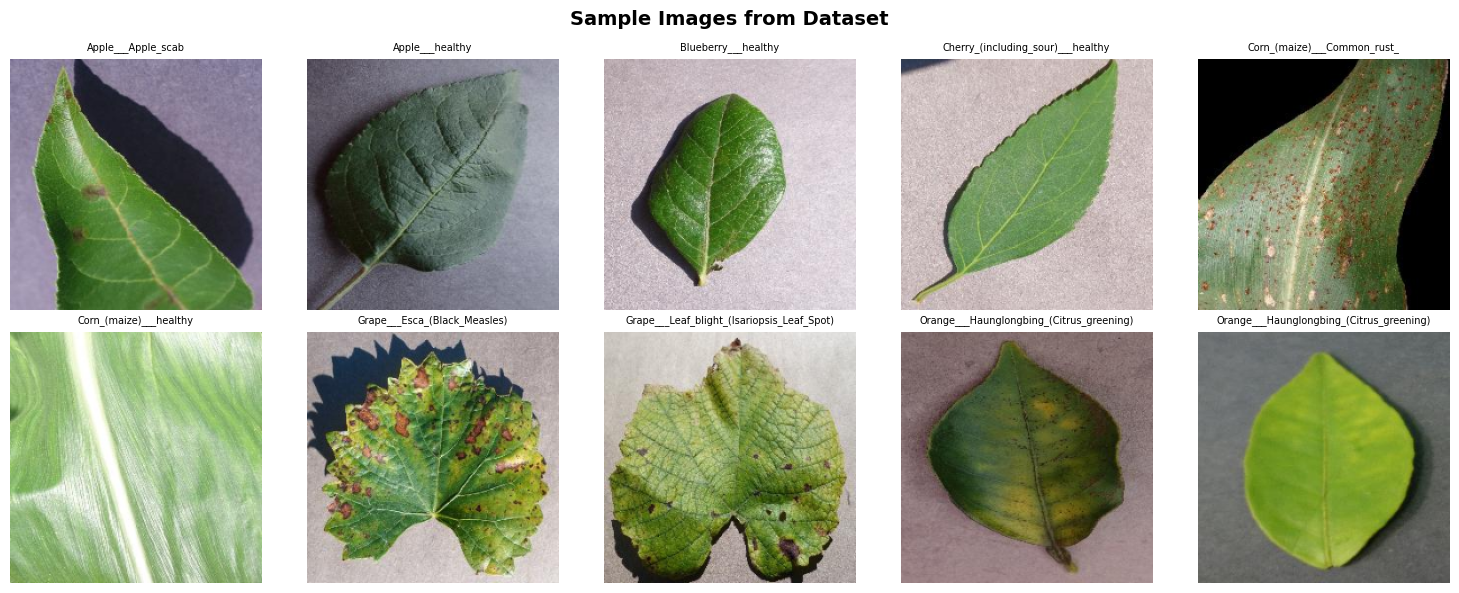

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Sample Images", fontsize=14, fontweight="bold")

for i, ax in enumerate(axes.flat):
    ax.imshow(images[i * 2000])
    ax.set_title(labels[i * 2000], fontsize=7)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
images_save_path = os.path.join(SAVE_PATH, "images.npy")
labels_save_path = os.path.join(SAVE_PATH, "labels.npy")

np.save(images_save_path, images)
np.save(labels_save_path, labels)

print()
print("Saved")
print(f"images.npy → {images_save_path}")
print(f"labels.npy → {labels_save_path}")


Saving images.npy ...
Saving labels.npy ...

Saved successfully!
  images.npy → /Users/manish/Documents/Semister 2/7. Project/Aarti Data Droplet/images.npy
  labels.npy → /Users/manish/Documents/Semister 2/7. Project/Aarti Data Droplet/labels.npy


In [ ]:
# Reload and check
images_check = np.load(images_save_path)
labels_check = np.load(labels_save_path, allow_pickle=True)

print(f"Images shape : {images_check.shape}")
print(f"Labels shape : {labels_check.shape}")
print(f"Classes : {len(np.unique(labels_check))}")
print()

# Class distribution
unique, counts = np.unique(labels_check, return_counts=True)
print("Images per class:")
for cls, cnt in zip(unique, counts):
    print(f"  {cnt:>5}  {cls}")


Images shape : (54305, 224, 224, 3)
Labels shape : (54305,)
Classes      : 38

Images per class:
    630  Apple___Apple_scab
    621  Apple___Black_rot
    275  Apple___Cedar_apple_rust
   1645  Apple___healthy
   1502  Blueberry___healthy
   1052  Cherry_(including_sour)___Powdery_mildew
    854  Cherry_(including_sour)___healthy
    513  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
   1192  Corn_(maize)___Common_rust_
    985  Corn_(maize)___Northern_Leaf_Blight
   1162  Corn_(maize)___healthy
   1180  Grape___Black_rot
   1383  Grape___Esca_(Black_Measles)
   1076  Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
    423  Grape___healthy
   5507  Orange___Haunglongbing_(Citrus_greening)
   2297  Peach___Bacterial_spot
    360  Peach___healthy
    997  Pepper,_bell___Bacterial_spot
   1478  Pepper,_bell___healthy
   1000  Potato___Early_blight
   1000  Potato___Late_blight
    152  Potato___healthy
    371  Raspberry___healthy
   5090  Soybean___healthy
   1835  Squash___Powdery_mild